# 11장 실습 ② — 임베딩은 무엇을 배웠나

**PyTorch 판**

학습이 끝난 모델에서 **임베딩 표를 꺼내 봅니다.**

데이터에는 *"좋다와 훌륭하다가 비슷한 뜻"* 이라는 정보가 **없었습니다.**
단어는 번호였고 정답은 0 아니면 1이었습니다. 그런데도 —

## 11.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 11.1 실험대 — 어순이 정답을 바꾸는 감성 분류

IMDB나 네이버 영화평은 **단어 가방만으로도 0.85 이상**이 나옵니다.
그러면 *"순서를 봐야 한다"* 는 이 장의 논증이 숫자로 드러나지 않습니다.

그래서 **어순이 정답을 바꾸도록** 만든 데이터를 씁니다.
인터넷 없이 만들어집니다. (3장 §3.2)

In [3]:
# 어순이 정답을 바꾸는 감성 분류. 인터넷 없이 만듭니다. (본문 §11.4)
V = len(data.TOY_VOCAB)
x, y = data.toy_reviews(n=8000, length=16, seed=42)
sp = data.split(x, y, val_ratio=0.2, test_ratio=0.2, seed=42)
print(sp.summary())
print(f"어휘 {V}개:", " ".join(data.TOY_VOCAB))
print()

for k in range(4):
    print(f"  {data.toy_decode(x[k]):<48} → {'긍정' if y[k] else '부정'}")

print()
print("★ 규칙 — 문장에 감성 단어 하나와 미끼 단어 하나가 있고,")
print("  부정어 '안'이 **둘 중 하나 앞에** 붙습니다.")
print("  '안'이 감성 단어에 붙었으면 정답이 뒤집힙니다.")
print()
print("  영화 안 좋다 정말 배우   → 부정")
print("  영화 좋다 안 정말 배우   → 긍정")
print()
print("  **두 문장에 든 단어의 집합은 같습니다.** 다른 것은 순서뿐입니다.")
print("  그래서 단어 가방으로는 **원리적으로** 풀 수 없습니다.")


def to_bag(seqs, vocab_size=V):
    """단어 가방 — 각 단어가 몇 번 나왔는지만 센다. **순서를 버린다.**"""
    b = np.stack([np.bincount(r, minlength=vocab_size) for r in seqs])
    b[:, 0] = 0                      # <pad>는 세지 않는다
    return b.astype("float32")

구분            개수  입력 shape
train       4800  (16,)
val         1600  (16,)
test        1600  (16,)
어휘 27개: <pad> 안 좋다 훌륭하다 재미있다 감동적이다 만족스럽다 나쁘다 지루하다 실망이다 형편없다 아쉽다 영화 배우 연출 이야기 장면 음악 정말 그냥 조금 매우 어제 친구랑 다시 역시 그리고

  다시 배우 안 형편없다 이야기 배우 그냥 정말 친구랑 친구랑                → 긍정
  정말 그냥 음악 안 재미있다 역시 배우 매우 정말                      → 부정
  배우 안 재미있다 역시 영화 정말 다시 장면                         → 부정
  배우 그리고 감동적이다 역시 어제 안 어제 친구랑 연출                   → 긍정

★ 규칙 — 문장에 감성 단어 하나와 미끼 단어 하나가 있고,
  부정어 '안'이 **둘 중 하나 앞에** 붙습니다.
  '안'이 감성 단어에 붙었으면 정답이 뒤집힙니다.

  영화 안 좋다 정말 배우   → 부정
  영화 좋다 안 정말 배우   → 긍정

  **두 문장에 든 단어의 집합은 같습니다.** 다른 것은 순서뿐입니다.
  그래서 단어 가방으로는 **원리적으로** 풀 수 없습니다.


## 11.2 모델 정의 — 여기만 판마다 다릅니다

**PyTorch 판에서 `Conv1d` 앞에 `transpose(1, 2)` 가 있는 것**에
주목하십시오. PyTorch는 (배치, **채널**, 길이) 를 받고 Keras는
(배치, 길이, **채널**) 을 받습니다. 자주 틀리는 자리입니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class TextModel(nn.Module):
    """임베딩 위에 무엇을 올리느냐만 다른 네 모델.

    Conv1d는 (배치, 채널, 길이) 를 받으므로 **축을 바꿔 줘야** 합니다.
    Keras의 Conv1D는 (배치, 길이, 채널) 을 받습니다. 여기가 다릅니다.
    """
    def __init__(self, kind, V, L, d=8):
        super().__init__()
        self.kind = kind
        if kind == "bow":
            self.body = nn.Sequential(nn.Linear(V, 16), nn.ReLU())
            n_out = 16
        else:
            self.emb = nn.Embedding(V, d)
            if kind == "avg":
                self.body = nn.Sequential(nn.Linear(d, 16), nn.ReLU())
                n_out = 16
            elif kind == "cnn":
                self.conv = nn.Conv1d(d, 16, 3); n_out = 16
            elif kind == "lstm":
                self.rnn = nn.LSTM(d, 32, batch_first=True); n_out = 32
        self.head = nn.Linear(n_out, 1)

    def forward(self, x):
        if self.kind == "bow":
            return self.head(self.body(x))
        e = self.emb(x.long())                      # (B, L, d)
        if self.kind == "avg":
            h = self.body(e.mean(1))
        elif self.kind == "cnn":
            h = torch.relu(self.conv(e.transpose(1, 2))).max(dim=2).values
        else:
            out, _ = self.rnn(e); h = out[:, -1]
        return self.head(h)

_FIT = {}

def train_text(kind, sp, lr=0.003, seed=42, epochs=25):
    """(시험 정확도, 파라미터 수, 임베딩 표) 를 돌려준다."""
    dlbook.set_seed(seed)
    V, L = len(data.TOY_VOCAB), sp.x_train.shape[1]
    prep = (lambda z: to_bag(z, V)) if kind == "bow" else (lambda z: z)
    model = TextModel(kind, V, L).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    clip = 1.0                        # 10장 §10.5의 권고 — 기울기 절단
    dl = DataLoader(TensorDataset(
        torch.tensor(prep(sp.x_train), dtype=torch.float32),
        torch.tensor(sp.y_train, dtype=torch.float32).view(-1, 1)),
        batch_size=64, shuffle=True)
    for _ in range(dlbook.smoke.epochs(epochs)):
        model.train()
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad(); loss_fn(model(xx), yy).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
    _FIT[kind] = (model, prep)
    n_params = sum(p.numel() for p in model.parameters())
    emb = (model.emb.weight.detach().cpu().numpy()
           if kind != "bow" else None)
    return predict_acc(kind, sp, sp.x_test), n_params, emb

def predict_acc(kind, sp, xs):
    """이미 학습된 모델로 임의의 입력에 대한 정확도를 잰다."""
    model, prep = _FIT[kind]
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(prep(xs), dtype=torch.float32).to(device))
    pred = (out.cpu().numpy().reshape(-1) > 0).astype(int)
    return metrics.accuracy(sp.y_test, pred)

## 11.1 학습하고, 임베딩 표를 꺼냅니다

In [5]:
# 학습된 LSTM에서 임베딩 표를 꺼냅니다.
acc, n_params, E = train_text("lstm", sp)
print(f"시험 정확도 {acc:.3f}, 임베딩 표 크기 {E.shape}")
print()
print("이 표는 **학습되는 파라미터**였습니다. 처음에는 난수였습니다.")
print("무엇이 되었는지 열어 봅니다.")

시험 정확도 1.000, 임베딩 표 크기 (27, 8)

이 표는 **학습되는 파라미터**였습니다. 처음에는 난수였습니다.
무엇이 되었는지 열어 봅니다.


## 11.2 단어 사이의 거리

In [6]:
# 거리는 **코사인 거리**로 잽니다.
# 프레임워크마다 임베딩 초기값의 크기가 달라(예: 균등 ±0.05 대 정규분포)
# 유클리드 거리는 판마다 자릿수가 달라집니다. 코사인은 방향만 보므로
# **세 판에서 같은 값**이 나옵니다. 0에 가까우면 같은 방향, 1이면 직각,
# 2면 정반대입니다.
def dist(a, b):
    i, j = data.TOY_VOCAB.index(a), data.TOY_VOCAB.index(b)
    u, v = E[i], E[j]
    return float(1.0 - u @ v / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12))

pairs = [("좋다", "훌륭하다"), ("나쁘다", "지루하다"), ("좋다", "나쁘다"),
         ("좋다", "영화"), ("안", "좋다")]

print(f"{'단어 쌍':<26}{'거리':>8}")
print("-" * 34)
for a, b in pairs:
    d = dist(a, b)
    print(f"{a + ' ↔ ' + b:<26}{d:>8.3f}")
    dlbook.record(f"ch11_dist_{a}_{b}", d)

# 한 쌍이 아니라 **무리끼리** 재 봅니다. 우연이 아님을 보이려면 이쪽이 낫습니다.
POS, NEG = data.TOY_VOCAB[2:7], data.TOY_VOCAB[7:12]
FILLER = data.TOY_VOCAB[12:]

def mean_dist(A, B):
    return float(np.mean([dist(a, b) for a in A for b in B if a != b]))

rows = [("긍정 무리 안에서", mean_dist(POS, POS)),
        ("부정 무리 안에서", mean_dist(NEG, NEG)),
        ("채움 무리 안에서", mean_dist(FILLER, FILLER)),
        ("긍정 ↔ 부정", mean_dist(POS, NEG)),
        ("'안' ↔ 나머지 전부", mean_dist(["안"], POS + NEG + FILLER))]

print()
print(f"{'무리':<26}{'평균 거리':>10}")
print("-" * 36)
for ko, v in rows:
    print(f"{ko:<26}{v:>10.3f}")
dlbook.record("ch11_grp_pos_in", rows[0][1])
dlbook.record("ch11_grp_neg_in", rows[1][1])
dlbook.record("ch11_grp_pos_neg", rows[3][1])
dlbook.record("ch11_grp_neg_word", rows[4][1])

print()
print("★ 데이터에는 '좋다'와 '훌륭하다'가 비슷하다는 정보가 **없었습니다.**")
print("  단어는 번호였고, 정답은 0 아니면 1이었습니다.")
print("  그런데도 같은 역할을 하는 단어끼리 열 배 넘게 가까워졌습니다.")

단어 쌍                            거리
----------------------------------
좋다 ↔ 훌륭하다                    0.155
ch11_dist_좋다_훌륭하다 = 0.1555
나쁘다 ↔ 지루하다                   0.286
ch11_dist_나쁘다_지루하다 = 0.2862
좋다 ↔ 나쁘다                     1.333
ch11_dist_좋다_나쁘다 = 1.3331
좋다 ↔ 영화                      1.059
ch11_dist_좋다_영화 = 1.0586
안 ↔ 좋다                       1.209
ch11_dist_안_좋다 = 1.2089

무리                             평균 거리
------------------------------------
긍정 무리 안에서                      0.374
부정 무리 안에서                      0.461
채움 무리 안에서                      1.010
긍정 ↔ 부정                        1.523
'안' ↔ 나머지 전부                   1.008
ch11_grp_pos_in = 0.3738
ch11_grp_neg_in = 0.4611
ch11_grp_pos_neg = 1.5234
ch11_grp_neg_word = 1.0078

★ 데이터에는 '좋다'와 '훌륭하다'가 비슷하다는 정보가 **없었습니다.**
  단어는 번호였고, 정답은 0 아니면 1이었습니다.
  그런데도 같은 역할을 하는 단어끼리 열 배 넘게 가까워졌습니다.


## 11.3 그림으로 — 8차원을 2차원으로

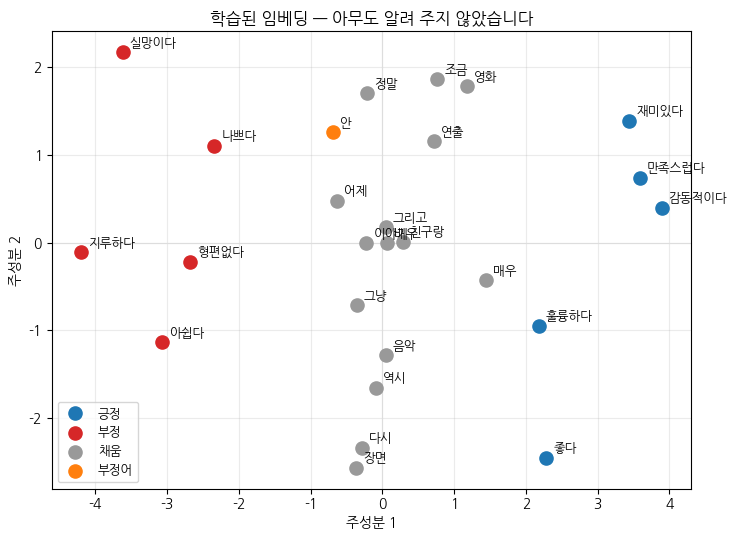

→ 긍정과 부정이 서로 반대편에 모였습니다.
→ 뜻이 없는 채움 단어들은 가운데에 뭉쳤습니다.
→ **'안'은 어느 무리에도 속하지 않습니다.** 긍정도 부정도 아니고,
   뒤에 오는 단어의 부호를 뒤집는 **연산자**이기 때문입니다.


In [7]:
# 8차원을 주성분 2개로 눌러서 그립니다. (numpy만 씁니다)
def pca2(M):
    C = M - M.mean(0, keepdims=True)
    _, _, Vt = np.linalg.svd(C, full_matrices=False)
    return C @ Vt[:2].T

P = pca2(E)
groups = {"긍정": data.TOY_VOCAB[2:7], "부정": data.TOY_VOCAB[7:12],
          "채움": data.TOY_VOCAB[12:], "부정어": ["안"]}
colors = {"긍정": "#1f77b4", "부정": "#d62728", "채움": "#999999",
          "부정어": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for g, words in groups.items():
    idx = [data.TOY_VOCAB.index(w) for w in words]
    ax.scatter(P[idx, 0], P[idx, 1], s=90, c=colors[g], label=g, zorder=3)
    for i in idx:
        ax.annotate(data.TOY_VOCAB[i], (P[i, 0], P[i, 1]),
                    fontsize=9, xytext=(5, 4), textcoords="offset points")
ax.axhline(0, color="#dddddd", lw=0.8); ax.axvline(0, color="#dddddd", lw=0.8)
ax.set_xlabel("주성분 1"); ax.set_ylabel("주성분 2")
ax.set_title("학습된 임베딩 — 아무도 알려 주지 않았습니다")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print("→ 긍정과 부정이 서로 반대편에 모였습니다.")
print("→ 뜻이 없는 채움 단어들은 가운데에 뭉쳤습니다.")
print("→ **'안'은 어느 무리에도 속하지 않습니다.** 긍정도 부정도 아니고,")
print("   뒤에 오는 단어의 부호를 뒤집는 **연산자**이기 때문입니다.")

## 정리

- **임베딩은 학습되는 조회표입니다.** 번호를 받아 벡터를 돌려줄 뿐이고,
  그 표가 역전파로 갱신됩니다.
- 아무도 알려 주지 않았는데 **같은 역할을 하는 단어가 같은 곳으로**
  모였습니다. 모델 입장에서 그것이 손실을 줄이는 가장 쉬운 길이기
  때문입니다.
- 담기는 것은 **뜻**이 아니라 **그 과제에서의 역할**입니다.
  품사 분류로 학습하면 "좋다"와 "나쁘다"가 붙습니다. 둘 다 형용사이기
  때문입니다. **임베딩은 과제의 거울입니다.**

### 연습

1. 임베딩 길이를 8에서 **2**로 줄이십시오. 성능이 유지됩니까.
   길이가 2이므로 **주성분 분석 없이 그대로 그릴 수 있습니다.**
2. Conv1D 모델의 임베딩을 꺼내 같은 그림을 그리십시오.
   LSTM의 것과 배치가 비슷합니까.
3. 학습을 **1 epoch만** 하고 그려 보십시오. 난수에서 얼마나 움직였습니까.
4. `toy_reviews()` 에서 부정어를 없앤 데이터를 만들고(감성 단어만 둘),
   "안"의 벡터가 어떻게 되는지 보십시오. **왜 그렇습니까.**
   (본문 「수식으로 한 번 더」의 역전파 식)